C:\Users\PHAMCX7\AppData\Local\anaconda3\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


--- KHỞI TẠO HỆ THỐNG MẠNG BAYES HỖ TRỢ CHẨN ĐOÁN Y TẾ ---
Đã tạo cấu trúc mạng y tế thành công.
Mô hình hợp lệ. Đã sẵn sàng suy luận chuyên gia.



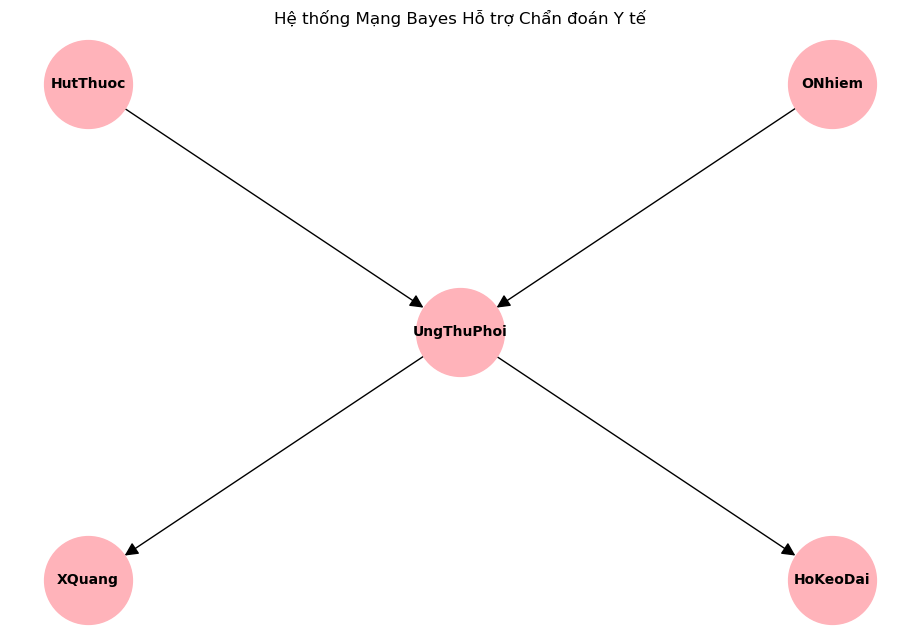


--- CHƯƠNG TRÌNH CHẨN ĐOÁN Y TẾ TƯƠNG TÁC ---

NHẬP THÔNG TIN BỆNH NHÂN MỚI (Nhấn Enter nếu chưa có xét nghiệm/chưa rõ)


- Bệnh nhân có hút thuốc không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  1
- Bệnh nhân sống ở vùng ô nhiễm không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  0
- Kết quả X-Quang có mờ/bất thường không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  1
- Bệnh nhân có ho kéo dài không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  1



ĐANG XỬ LÝ SUY DIỄN BẰNG MẠNG BAYES...
Các bằng chứng đã ghi nhận: {'HutThuoc': 1, 'ONhiem': 0, 'XQuang': 1, 'HoKeoDai': 1}
=> KẾT QUẢ DỰ ĐOÁN KHẢ NĂNG MẮC UNG THƯ PHỔI:
+---------------+-------------------+
| UngThuPhoi    |   phi(UngThuPhoi) |
+===============+===================+
| UngThuPhoi(0) |            0.0769 |
+---------------+-------------------+
| UngThuPhoi(1) |            0.9231 |
+---------------+-------------------+



Bạn có muốn chẩn đoán bệnh nhân khác? (Nhập 'k' để THOÁT, phím bất kỳ để TIẾP TỤC):  f



NHẬP THÔNG TIN BỆNH NHÂN MỚI (Nhấn Enter nếu chưa có xét nghiệm/chưa rõ)


- Bệnh nhân có hút thuốc không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  0
- Bệnh nhân sống ở vùng ô nhiễm không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  0
- Kết quả X-Quang có mờ/bất thường không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  1
- Bệnh nhân có ho kéo dài không? (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết):  1



ĐANG XỬ LÝ SUY DIỄN BẰNG MẠNG BAYES...
Các bằng chứng đã ghi nhận: {'HutThuoc': 0, 'ONhiem': 0, 'XQuang': 1, 'HoKeoDai': 1}
=> KẾT QUẢ DỰ ĐOÁN KHẢ NĂNG MẮC UNG THƯ PHỔI:
+---------------+-------------------+
| UngThuPhoi    |   phi(UngThuPhoi) |
+===============+===================+
| UngThuPhoi(0) |            0.4783 |
+---------------+-------------------+
| UngThuPhoi(1) |            0.5217 |
+---------------+-------------------+


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork # Changed BayesianNetwork to DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

print("--- KHỞI TẠO HỆ THỐNG MẠNG BAYES HỖ TRỢ CHẨN ĐOÁN Y TẾ ---")

# BƯỚC 1: XÂY DỰNG CẤU TRÚC MẠNG NGHIỆP VỤ Y TẾ
# Định nghĩa các yếu tố nguy cơ (Nguyên nhân) và triệu chứng (Kết quả)
# Mối quan hệ: Hút thuốc & Ô nhiễm không khí -> Gây Ung thư phổi -> Gây Ho kéo dài & X-Quang dương tính
model = DiscreteBayesianNetwork([ # Changed BayesianNetwork to DiscreteBayesianNetwork
    ('HutThuoc', 'UngThuPhoi'),     # Hút thuốc -> Dễ bị Ung thư phổi
    ('ONhiem', 'UngThuPhoi'),       # Môi trường ô nhiễm -> Dễ bị Ung thư phổi
    ('UngThuPhoi', 'XQuang'),       # Bị ung thư -> Kết quả chụp X-Quang có vết mờ (Dương tính)
    ('UngThuPhoi', 'HoKeoDai')      # Bị ung thư -> Thường bị ho kéo dài
])

print("Đã tạo cấu trúc mạng y tế thành công.")

# BƯỚC 2: KHAI BÁO DỮ LIỆU LỊCH SỬ / CHUYÊN GIA (CPT - Conditional Probability Tables)
# Quy ước: 0 là Không (False), 1 là Có (True)

# 1. Xác suất một bệnh nhân ngẫu nhiên có hút thuốc (dựa trên thống kê dân số là 30%)
cpd_hutthuoc = TabularCPD(variable='HutThuoc', variable_card=2,
                          values=[[0.70],   # P(HutThuoc=0) = 70%
                                  [0.30]])  # P(HutThuoc=1) = 30%

# 2. Xác suất bệnh nhân sống trong môi trường ô nhiễm cao (giả sử 10%)
cpd_onhiem = TabularCPD(variable='ONhiem', variable_card=2,
                        values=[[0.90],     # P(ONhiem=0) = 90%
                                [0.10]])    # P(ONhiem=1) = 10%

# 3. Xác suất mắc Ung thư phổi dựa vào yếu tố Hút thuốc và Ô nhiễm
# Cột: [HutThuoc=0, ONhiem=0], [HutThuoc=0, ONhiem=1], [HutThuoc=1, ONhiem=0], [HutThuoc=1, ONhiem=1]
cpd_ungthu = TabularCPD(variable='UngThuPhoi', variable_card=2,
                        values=[[0.99, 0.95, 0.90, 0.80],   # P(Không bị Ung thư)
                                [0.01, 0.05, 0.10, 0.20]],  # P(Bị Ung thư)
                        evidence=['HutThuoc', 'ONhiem'],
                        evidence_card=[2, 2])

# 4. Xác suất X-Quang trả về Dương tính dựa trên việc có bị Ung thư hay không
# Lưu ý: Có tỷ lệ dương tính giả (5%) và âm tính giả (10%)
# Cột: [UngThuPhoi=0], [UngThuPhoi=1]
cpd_xquang = TabularCPD(variable='XQuang', variable_card=2,
                        values=[[0.95, 0.10],   # P(XQuang=Âm tính)
                                [0.05, 0.90]],  # P(XQuang=Dương tính)
                        evidence=['UngThuPhoi'], evidence_card=[2])

# 5. Xác suất bị Ho kéo dài dựa trên việc có bị Ung thư hay không
# Cột: [UngThuPhoi=0], [UngThuPhoi=1]
cpd_ho = TabularCPD(variable='HoKeoDai', variable_card=2,
                    values=[[0.90, 0.40],   # P(Ho=Không) -> (10% người bình thường vẫn ho, 60% người bệnh bị ho)
                            [0.10, 0.60]],  # P(Ho=Có)
                    evidence=['UngThuPhoi'], evidence_card=[2])

# BƯỚC 3: KIỂM TRA MÔ HÌNH
model.add_cpds(cpd_hutthuoc, cpd_onhiem, cpd_ungthu, cpd_xquang, cpd_ho)

if model.check_model():
    print("Mô hình hợp lệ. Đã sẵn sàng suy luận chuyên gia.\n")
else:
    print("Có lỗi trong cấu hình xác suất.")

# BƯỚC 4: VẼ SƠ ĐỒ CHẨN ĐOÁN TRỰC QUAN
plt.figure(figsize=(9, 6))
pos = {'HutThuoc': (0, 2), 'ONhiem': (2, 2), 'UngThuPhoi': (1, 1),
       'XQuang': (0, 0), 'HoKeoDai': (2, 0)}
nx.draw(model, pos, with_labels=True, node_size=4000, node_color='#ffb3ba',
        font_size=10, font_weight='bold', arrowsize=20)
plt.title("Hệ thống Mạng Bayes Hỗ trợ Chẩn đoán Y tế")
plt.show(block=False)
plt.pause(0.1) # Thêm một nhịp nghỉ nhỏ để đồ thị kịp vẽ lên

# BƯỚC 5: ỨNG DỤNG NGHIỆP VỤ (TƯƠNG TÁC NHẬP LIỆU BỞI BÁC SĨ)
print("\n--- CHƯƠNG TRÌNH CHẨN ĐOÁN Y TẾ TƯƠNG TÁC ---")
infer = VariableElimination(model)

def nhap_lieu(cau_hoi):
    """Hàm hỗ trợ lấy dữ liệu an toàn từ người dùng"""
    while True:
        tra_loi = input(f"{cau_hoi} (Nhập 1: Có, 0: Không, Enter: Bỏ qua nếu chưa biết): ").strip()
        if tra_loi == '1':
            return 1
        elif tra_loi == '0':
            return 0
        elif tra_loi == '':
            return None # Bỏ qua (Missing data)
        else:
            print("  -> Lỗi: Vui lòng chỉ nhập 1, 0 hoặc nhấn Enter!")

# Vòng lặp tương tác để chẩn đoán nhiều bệnh nhân
while True:
    print("\n" + "="*60)
    print("NHẬP THÔNG TIN BỆNH NHÂN MỚI (Nhấn Enter nếu chưa có xét nghiệm/chưa rõ)")

    evidence = {}

    # 1. Thu thập dữ liệu
    ht = nhap_lieu("- Bệnh nhân có hút thuốc không?")
    if ht is not None: evidence['HutThuoc'] = ht

    on = nhap_lieu("- Bệnh nhân sống ở vùng ô nhiễm không?")
    if on is not None: evidence['ONhiem'] = on

    xq = nhap_lieu("- Kết quả X-Quang có mờ/bất thường không?")
    if xq is not None: evidence['XQuang'] = xq

    ho = nhap_lieu("- Bệnh nhân có ho kéo dài không?")
    if ho is not None: evidence['HoKeoDai'] = ho

    # 2. Xử lý suy diễn bằng Mạng Bayes
    print("\nĐANG XỬ LÝ SUY DIỄN BẰNG MẠNG BAYES...")
    print(f"Các bằng chứng đã ghi nhận: {evidence if evidence else 'Không có'}")

    try:
        if not evidence:
            print("=> Cảnh báo: Chưa nhập thông tin! Xác suất mắc bệnh của một người ngẫu nhiên là:")
            ket_qua = infer.query(variables=['UngThuPhoi'])
        else:
            print("=> KẾT QUẢ DỰ ĐOÁN KHẢ NĂNG MẮC UNG THƯ PHỔI:")
            ket_qua = infer.query(variables=['UngThuPhoi'], evidence=evidence)
        print(ket_qua)
    except Exception as e:
        print("Đã xảy ra lỗi trong quá trình suy diễn:", e)

    # 3. Hỏi người dùng có muốn tiếp tục
    tiep_tuc = input("\nBạn có muốn chẩn đoán bệnh nhân khác? (Nhập 'k' để THOÁT, phím bất kỳ để TIẾP TỤC): ").strip().lower()
    if tiep_tuc == 'k':
        print("Đã thoát chương trình hỗ trợ chẩn đoán.")
        break